****
IMPORT
****

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split, GridSearchCV, cross_val_predict
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve, classification_report

****
TRAIN / TEST
****

In [2]:
# 1. Chargement du dataset de training choisi
df_ml = pd.read_parquet("../data/dataframe_training.parquet")

# 2. Séparation de la cible (y) et des caractéristiques (X)
# On supprime explicitement la cible et l'identifiant pour la matrice X
X = df_ml.drop(columns=['a_quitte_l_entreprise', 'id_user'], errors='ignore')
y = df_ml['a_quitte_l_entreprise']

# 3. Création des jeux d'apprentissage et de test (Stratified pour équilibrer le turnover)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"📦 Jeux d'apprentissage et de test créés avec succès !")
print(f"Train set (X_train) : {X_train.shape[0]} lignes | Test set (X_test) : {X_test.shape[0]} lignes")

📦 Jeux d'apprentissage et de test créés avec succès !
Train set (X_train) : 1176 lignes | Test set (X_test) : 294 lignes


****
Modèles
****

In [3]:
# 1. Modèle Baseline / Dummy (Prédit toujours la classe la plus fréquente)
model_dummy = DummyClassifier(strategy="most_frequent")
model_dummy.fit(X_train, y_train)

# 2. Modèle Linéaire (Régression Logistique)
# max_iter augmenté pour garantir la convergence mathématique
model_linear = LogisticRegression(max_iter=1000, random_state=42)
model_linear.fit(X_train, y_train)

# 3. Modèle Non-Linéaire (Random Forest - Optimal pour le Label Encoding)
model_nonlinear = RandomForestClassifier(n_estimators=100, random_state=42)
model_nonlinear.fit(X_train, y_train)

print("🎯 Les 3 modèles ont été entraînés avec succès sur le jeu d'apprentissage !")

c:\Users\ThibautSénéchal\Code\3_automatically_classify_information\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


🎯 Les 3 modèles ont été entraînés avec succès sur le jeu d'apprentissage !


`DETAIL`
- Dummy => Établit la baseline la plus logique face à un dataset déséquilibré. Le modèle prédit aveuglément la situation majoritaire, ici l'employé qui reste.
- Linear (max_iter=1000) => Augmenté par rapport à la valeur par défaut (100) pour garantir la convergence mathématique de l'algorithme. Les données contenant plusieurs features créées et des échelles différentes, cela donne au solveur linéaire le temps de trouver la frontière de décision optimale sans planter.
- NonLinear (n_estimators=100) => Paramètre standard et robuste qui instancie un ensemble de 100 arbres de décision indépendants. Ce nombre offre un excellent compromis entre puissance prédictive et temps de calcul, tout en réduisant la variance globale par rapport à un arbre de décision unique.
- random_state=42 => Fixe la graine aléatoire pour garantir la reproductibilité stricte des résultats.

****
Métriques
****

In [4]:
# Fonction d'extraction automatique des métriques
def extraire_metriques(model, X, y, nom_jeu):
    y_pred = model.predict(X)
    return {
        f"Accuracy ({nom_jeu})": accuracy_score(y, y_pred),
        f"Precision ({nom_jeu})": precision_score(y, y_pred, zero_division=0),
        f"Recall ({nom_jeu})": recall_score(y, y_pred, zero_division=0),
        f"F1-Score ({nom_jeu})": f1_score(y, y_pred, zero_division=0)
    }

# Compilation des résultats pour chaque modèle
dict_resultats = {}

for nom, model in [("Modèle Dummy", model_dummy), ("Modèle Linéaire (LogReg)", model_linear), ("Modèle Non-Linéaire (RF)", model_nonlinear)]:
    # Métriques d'apprentissage
    metriques_train = extraire_metriques(model, X_train, y_train, "Train")
    # Métriques de validation (Test)
    metriques_test = extraire_metriques(model, X_test, y_test, "Test")
    
    # Fusion des dictionnaires pour ce modèle
    dict_resultats[nom] = {**metriques_train, **metriques_test}

# Conversion en DataFrame pour affichage propre sous forme de tableau
df_metriques = pd.DataFrame(dict_resultats).T

# Réorganisation esthétique des colonnes (Train à côté de Test)
colonnes_ordonnees = [
    "Accuracy (Train)", "Accuracy (Test)",
    "Precision (Train)", "Precision (Test)",
    "Recall (Train)", "Recall (Test)",
    "F1-Score (Train)", "F1-Score (Test)"
]

# Affichage du tableau final arrondi à 3 décimales
display(df_metriques[colonnes_ordonnees].round(3))

,Accuracy (Train),Accuracy (Test),Precision (Train),Precision (Test),Recall (Train),Recall (Test),F1-Score (Train),F1-Score (Test)
Modèle Dummy,0.838,0.840,0.000,0.000,0.000,0.000,0.000,0.000
Modèle Linéaire (LogReg),0.860,0.844,0.745,0.533,0.200,0.170,0.315,0.258
Modèle Non-Linéaire (RF),0.999,0.827,1.000,0.375,0.995,0.128,0.997,0.190


`OBSERVATION:`
- Dummy => Ce modèle "naïf" se contente de prédire la classe majoritaire (l'employé reste) car le dataset est déséquilibré. Il prouve que l'Accuracy est une métrique trompeuse ici : un modèle peut sembler performant tout en étant totalement incapable de détecter la moindre démission
- Linear => Sa précision indique qu'il est capable de prédir plus d'un départ sur 2. Moins sensible au surapprentissage que le Random Forest, il reste cependant limité par le déséquilibre des classes. Son Recall de 0.170 montre qu'il ne parvient pas à intercepter efficacement les signaux faibles de turnover.
- NonLinear => Des scores quasi-parfaits sur le jeu d'entraînement qui s'effondrent sur le jeu de test. C'est un cas d'overfitting.

``Ces résultats indique clairement que le dataset est trop déséquilibré et nécessite un rééquilibrage ou l'adaptation de paramètre des modèles.``

`Réflexion Méthodologique:`
- Faux Négatif (Le pire scénario) : Le modèle prédit que l'employé reste (0), mais il démissionne (1). L'entreprise subit un départ surprise, la perte d'un talent, et des coûts de recrutement imprévus.
- Faux Positif (Le scénario gérable) : Le modèle prédit que l'employé va partir (1), mais il reste (0). Les RH vont peut-être lui proposer un entretien, une petite augmentation ou une formation pour le retenir. C'est un coût de prévention, mais l'employé est toujours là.

- Conclusion : Il vaut mieux alerter à tort que de rater un départ. Il faudra donc prioriser la métrique Recall tout en garadant une bonne Précision.

****
Validation Croisée
****

In [5]:
# 1. Fonction d'évaluation en Cross-Validation
def evaluer_modele_cv(model, X_train, y_train, n_splits=5):
    """
    Évalue un modèle avec Stratified K-Fold et retourne les moyennes/écarts-types.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scoring = ['recall', 'precision', 'f1']
    
    # Exécution de la validation croisée
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=True)
    
    # Affichage propre des résultats
    print(f"--- Résultats Validation Croisée ({n_splits} Folds) ---")
    
    # On regarde le train vs test pour vérifier l'Overfit
    print(f"F1-Score (Train) : {scores['train_f1'].mean():.3f} +/- {scores['train_f1'].std():.3f}")
    print(f"F1-Score (Test)  : {scores['test_f1'].mean():.3f} +/- {scores['test_f1'].std():.3f}")
    print("-" * 30)
    print(f"Recall (Test)    : {scores['test_recall'].mean():.3f} +/- {scores['test_recall'].std():.3f}")
    print(f"Precision (Test) : {scores['test_precision'].mean():.3f} +/- {scores['test_precision'].std():.3f}")
    
    return scores

****
Modèle Non-Linéaire équilibré
****

In [6]:
# 1. On définit le modèle de base (toujours équilibré)
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# 2. On définit la "grille" des paramètres à tester
# Le modèle va tester chaque max_depth combiné avec chaque min_samples_leaf
grille_parametres = {
    'max_depth': [3, 4, 5, 6, 7],
    'min_samples_leaf': [1, 5, 10],
    'n_estimators': [100]
}

# 3. Lancement du GridSearchCV (optimisé pour le F1-Score)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=grille_parametres,
    scoring='f1',       # On demande à la machine de maximiser le F1-Score
    cv=5,               # Validation croisée à 5 plis intégrée
    n_jobs=-1,          # Utilise tous les coeurs de ton processeur pour aller plus vite
    verbose=1
)

# Entraînement de la grille sur les données
grid_search.fit(X_train, y_train)

# 4. Affichage du grand gagnant !
print("🏆 Meilleurs hyperparamètres trouvés par la machine :")
print(grid_search.best_params_)

# Tu peux extraire le meilleur modèle directement pour la suite
meilleur_modele_rf = grid_search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
🏆 Meilleurs hyperparamètres trouvés par la machine :
{'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 100}


In [7]:
# 1. Extraction directe du meilleur modèle entraîné par le GridSearch
rf_balanced_optimal = grid_search.best_estimator_

# 2. Lancement de ta validation croisée pour afficher les résultats
print("📊 Évaluation du Meilleur Random Forest (Trouvé par GridSearch) :")
resultats_cv = evaluer_modele_cv(rf_balanced_optimal, X_train, y_train)

# (Optionnel) Le modèle extrait est déjà entraîné, mais pour garantir 
# que ton pipeline soit clair, tu peux le ré-entraîner explicitement sur tout le Train :
rf_balanced_optimal.fit(X_train, y_train)

📊 Évaluation du Meilleur Random Forest (Trouvé par GridSearch) :
--- Résultats Validation Croisée (5 Folds) ---
F1-Score (Train) : 0.622 +/- 0.011
F1-Score (Test)  : 0.457 +/- 0.060
------------------------------
Recall (Test)    : 0.532 +/- 0.090
Precision (Test) : 0.405 +/- 0.057


RandomForestClassifier(class_weight='balanced', max_depth=5,
                       min_samples_leaf=10, random_state=42)

`Observation:`
- On a une bonne augmentation du Recall comme voulu puique nous sommes passé de 12 à 53% sur le jeu de test tout en améliorant légèrement la précision. l'algorithme à donc bien cessé d'ignorer la classe minoritaire.
- Quand on regarde l'écart des F1-score être test et train on observe toujours overfitting.

****
Graphique
****

📊 Performances théoriques au point optimal (Point Rouge) :
 - Seuil optimal : 0.501
 - Recall        : 0.537
 - Precision     : 0.411


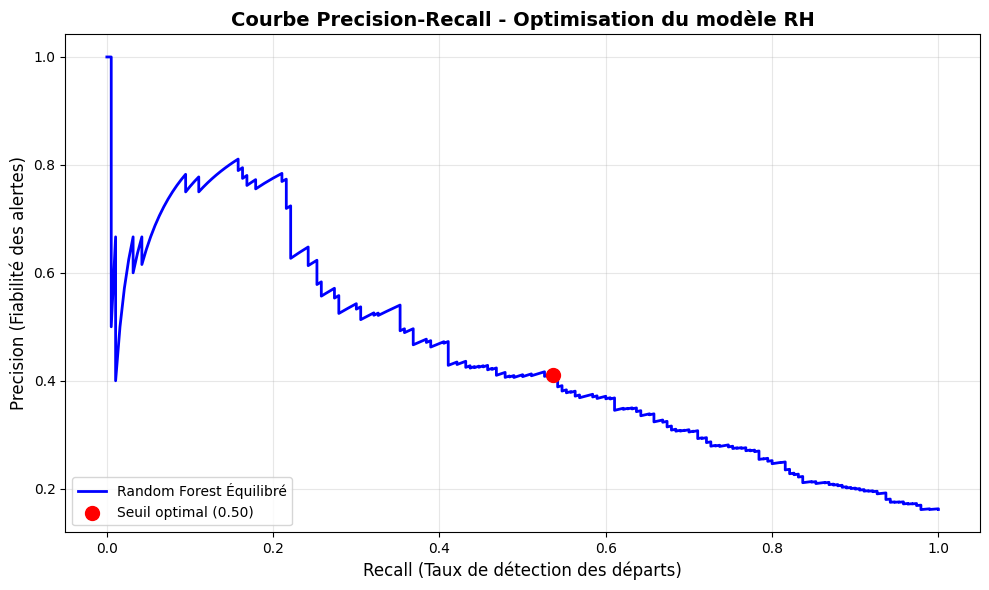

In [14]:
# 1. Calcul des probabilités de départ sur le jeu de test
y_probs_cv = cross_val_predict(rf_balanced_optimal, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# 2. Calcul des points de la courbe Precision-Recall
precisions_cv, recalls_cv, seuils_cv = precision_recall_curve(y_train, y_probs_cv)

# 3. Recherche du seuil qui maximise le F1-Score
# Attention : la liste 'seuils' a un élément de moins que precisions/recalls
f1_scores = 2 * (precisions_cv[:-1] * recalls_cv[:-1]) / (precisions_cv[:-1] + recalls_cv[:-1])
meilleur_index = np.argmax(f1_scores)
meilleur_seuil = seuils_cv[meilleur_index]

print("📊 Performances théoriques au point optimal (Point Rouge) :")
print(f" - Seuil optimal : {meilleur_seuil:.3f}")
print(f" - Recall        : {recalls_cv[meilleur_index]:.3f}")
print(f" - Precision     : {precisions_cv[meilleur_index]:.3f}")

# 4. Tracé du graphique
plt.figure(figsize=(10, 6))
plt.plot(recalls_cv, precisions_cv, label='Random Forest Équilibré', color='b', linewidth=2)
plt.scatter(recalls_cv[meilleur_index], precisions_cv[meilleur_index], color='red', s=100, zorder=5, 
            label=f'Seuil optimal ({meilleur_seuil:.2f})')

plt.title('Courbe Precision-Recall - Optimisation du modèle RH', fontsize=14, fontweight='bold')
plt.xlabel('Recall (Taux de détection des départs)', fontsize=12)
plt.ylabel('Precision (Fiabilité des alertes)', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

`Observation`
- Le seuil optimal est prohe du seuil par default de 0.5 et améliore légèrement les resultat recall comme précision.
- On peux aussi observé selon les objectifs quel y_pred définir selon les objectifs, es que l'on souhaite diminuer les faux positif ou negatif. Jouant ainsi sur le ratio précision/recall.

****
Métriques
****

In [17]:
# 1. Application du seuil sur les probabilités de la Validation Croisée
y_pred_cv_optimal = (y_probs_cv >= meilleur_seuil).astype(int)

# 2. Rapport de Classification (On compare avec y_train !)
print("📊 Rapport de Classification - Validation Croisée (Seuil Optimal) :")
print(classification_report(y_train, y_pred_cv_optimal, target_names=["Reste (0)", "Part (1)"]))

📊 Rapport de Classification - Validation Croisée (Seuil Optimal) :
              precision    recall  f1-score   support

   Reste (0)       0.91      0.85      0.88       986
    Part (1)       0.41      0.54      0.47       190

    accuracy                           0.80      1176
   macro avg       0.66      0.69      0.67      1176
weighted avg       0.83      0.80      0.81      1176



`Observation:`
- On obtiens bien les résultat attendu part le graphique de courbe precision-recall.

In [18]:
# 1. Le modèle calcule les probabilités sur le NOUVEAU jeu (Test)
y_probs_test = rf_balanced_optimal.predict_proba(X_test)[:, 1]

# 2. Application de ton seuil optimal trouvé précédemment
y_pred_test_optimal = (y_probs_test >= meilleur_seuil).astype(int)

# 3. Rapport de Classification Final (On compare avec y_test)
print("🏆 Rapport de Classification FINAL sur le Test (Seuil Optimal) :")
print(classification_report(y_test, y_pred_test_optimal, target_names=["Reste (0)", "Part (1)"]))

🏆 Rapport de Classification FINAL sur le Test (Seuil Optimal) :
              precision    recall  f1-score   support

   Reste (0)       0.89      0.82      0.85       247
    Part (1)       0.32      0.45      0.37        47

    accuracy                           0.76       294
   macro avg       0.60      0.63      0.61       294
weighted avg       0.80      0.76      0.77       294



`Observation:`
- On voit une regression par rapport a la moyenne des modèles croisé, une précision et recall significativement plus faible.
- Cette baisse s'explique par deux phénomènes :
- - Un léger surapprentissage (overfitting) : Le modèle a un peu trop mémorisé les spécificités de l'entraînement et perd en capacité de généralisation face à de nouveaux profils.
- - La taille de l'échantillon (Variance) : Le jeu de test contient très peu de vrais départs (47). Sur un volume aussi restreint, rater ne serait-ce que 3 ou 4 prédictions fait chuter les pourcentages de manière drastique.

`Conclusion:`
- Le modèle Random Forest classique à été poussé à ses limites mathématiques (optimisation des hyperparamètres + ajustement du seuil métier). Le léger décrochage sur le jeu de test montre que jongler avec le paramètre class_weight ne suffit plus à compenser le manque cruel de données de départs. Pour franchir un nouveau cap, il faut désormais créer de la donnée synthétique avec la technique du SMOTE (Oversampling)